# **DEFENSE FIGURE — H2: the AMOC manifold is flat**
---
**Purpose (thesis defense, not part of the analysis pipeline).** Produce a single
figure showing that **two coordinates suffice** to describe the RAPID vertical
profiles: for three representative days the true profile Ψ(z) and its
reconstruction from `mean_profile + PC1·b1 + PC2·b2` (k = 2) are nearly
indistinguishable.

This notebook is **standalone**. It does not modify NB03/NB05 — it *copies* their
data-loading and PCA logic (same file, same paths, `load_rapid_vertical()`), so the
numbers are identical to the thesis.

**Chosen days** (confirmed): Strong = **2015-11-18** (≈p95), Weak = **2014-03-08**
(≈p5), Anomalous = **2009-12-23** (the 2009–10 event minimum, also Isolation-Forest
flagged in NB04).

**Output:** `../img/H2_reconstruction_overlay.png` (white background) and
`../img/H2_reconstruction_overlay_transparent.png` (dpi 300, transparent).

In [1]:
# --- Setup (data-loading logic copied from NB03) ---
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_CODE = NOTEBOOK_DIR.parent            # notebooks/ -> 04_Code/
if str(PROJECT_CODE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from pipeline.data_loading import load_rapid_vertical

# Defense figures go to ../img/ (create if missing) — NOT into notebooks/
IMG_DIR = (NOTEBOOK_DIR.parent / "img")
IMG_DIR.mkdir(parents=True, exist_ok=True)
print("Figures ->", IMG_DIR.resolve())

Figures -> C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\04_Code\img


In [2]:
# --- Load RAPID vertical profiles + PCA (identical to NB03) ---
ds_vert = load_rapid_vertical()
profiles = ds_vert['stream_function_mar'].transpose('time', 'depth')  # (time, depth)
X = profiles.values
depth = ds_vert['depth'].values

# Drop the 3 fully-NaN tail days (26-27 Mar 2024), exactly as NB03
valid_days = ~np.isnan(X).any(axis=1)
X_clean = X[valid_days]
times_clean = pd.to_datetime(ds_vert['time'].values[valid_days])
assert not np.isnan(X_clean).any()

# Covariance-based PCA: centered (default), unscaled — identical to NB03
pca = PCA()
scores = pca.fit_transform(X_clean)
mean_profile = pca.mean_          # climatological mean profile  (307,)
comp = pca.components_            # unit loadings b_k             (n, 307)
pc1, pc2 = scores[:, 0], scores[:, 1]
expl = pca.explained_variance_ratio_

print(f"profiles: {X_clean.shape}")
print(f"PC1={expl[0]*100:.2f}%  PC2={expl[1]*100:.2f}%  cumulative(2)={expl[:2].sum()*100:.2f}%")

profiles: (14596, 307)
PC1=89.82%  PC2=8.03%  cumulative(2)=97.86%


In [3]:
# --- The three representative profiles (confirmed for the defense) ---
# RAPID Psi(z) is sampled twice daily (00:00 & 12:00). On each chosen calendar
# date we take the most extreme 12-hourly sample in the relevant direction, so
# the reported PC1 values are unambiguous and reproducible.
selection = [
    ("Strong AMOC",                "2015-11-18", "max"),   # ~p95 intensity, typical strong
    ("Weak AMOC",                  "2014-03-08", "min"),   # ~p5  intensity, typical weak
    ("Anomalous  (2009-10 event)", "2009-12-23", "min"),   # event minimum, IF-flagged in NB04
]

day = times_clean.normalize()   # calendar date of every sample

picks = []
for label, date_str, direction in selection:
    m = np.where(day.values == np.datetime64(date_str))[0]
    i = int(m[np.argmax(pc1[m])] if direction == "max" else m[np.argmin(pc1[m])])
    true_p  = X_clean[i]
    recon_p = mean_profile + scores[i, 0]*comp[0] + scores[i, 1]*comp[1]   # k = 2
    rmse = float(np.sqrt(np.mean((true_p - recon_p)**2)))
    picks.append(dict(label=label, i=i, date=times_clean[i],
                      true=true_p, recon=recon_p, rmse=rmse,
                      pc1=pc1[i], pc2=pc2[i]))
    print(f"{label:28s} {times_clean[i]}  idx={i:5d}  "
          f"PC1={pc1[i]:+7.1f}  PC2={pc2[i]:+6.1f}  peak={true_p.max():+5.1f}Sv  "
          f"RMSE(k=2)={rmse:.3f} Sv")

Strong AMOC                  2015-11-18 12:00:00  idx= 8495  PC1=  +88.7  PC2= +18.6  peak=+26.1Sv  RMSE(k=2)=0.375 Sv
Weak AMOC                    2014-03-08 12:00:00  idx= 7255  PC1=  -92.9  PC2= -28.5  peak= +8.0Sv  RMSE(k=2)=0.370 Sv
Anomalous  (2009-10 event)   2009-12-23 00:00:00  idx= 4182  PC1= -240.4  PC2= -29.8  peak= +0.0Sv  RMSE(k=2)=0.442 Sv


saved:
   C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\04_Code\img\H2_reconstruction_overlay.png
   C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\04_Code\img\H2_reconstruction_overlay_transparent.png


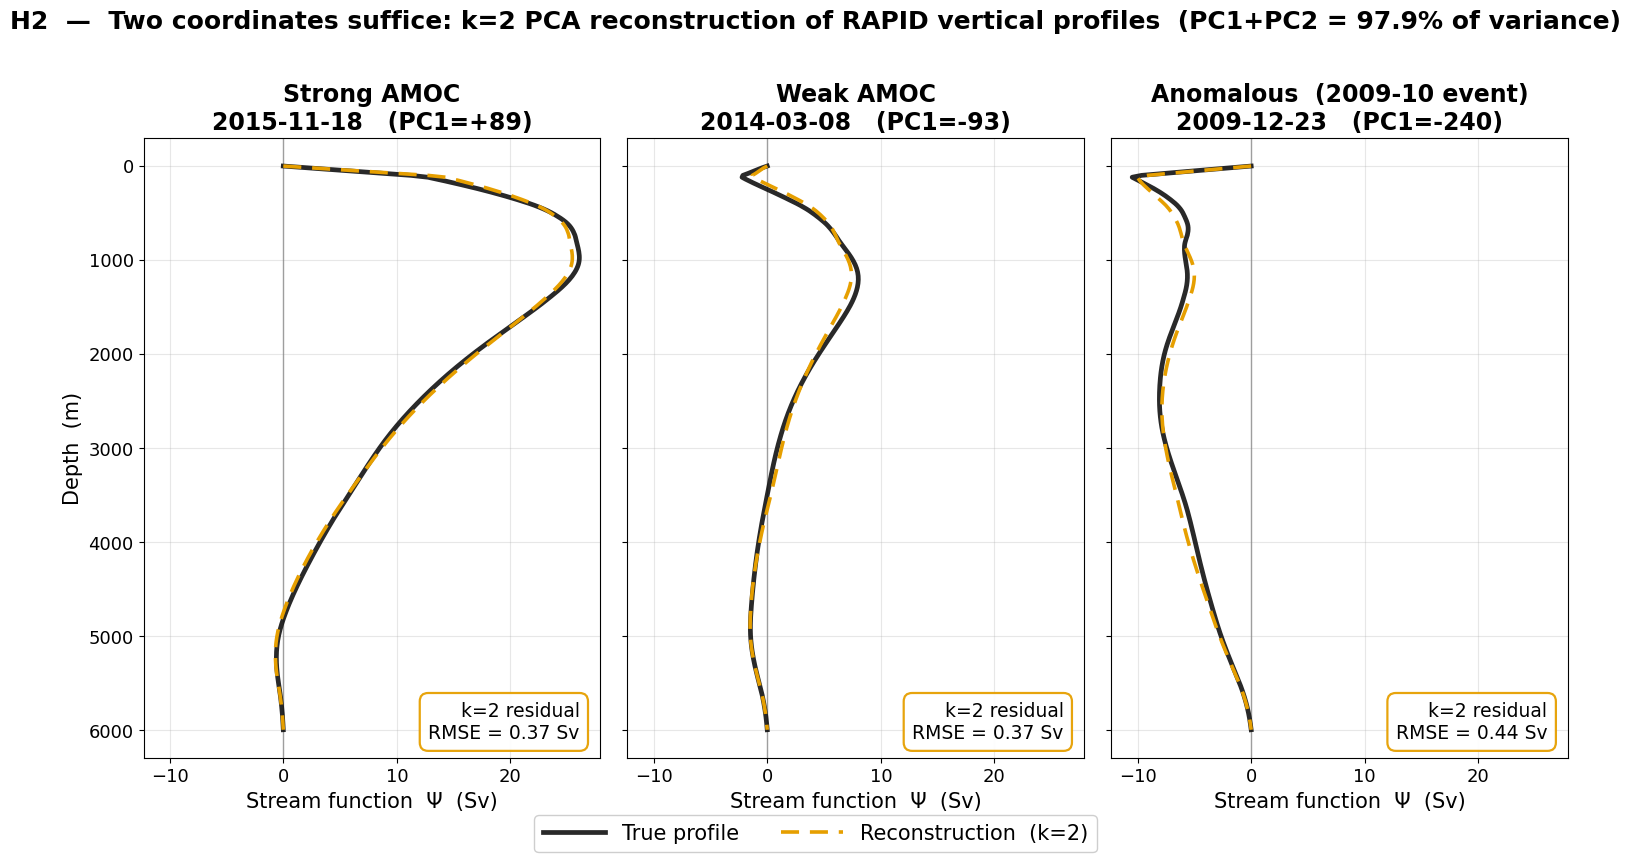

In [4]:
# --- The figure: true vs k=2 reconstruction, oceanographic orientation ---
plt.rcParams.update({
    'font.size': 15, 'axes.titlesize': 17, 'axes.labelsize': 15,
    'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 14,
    'axes.grid': True, 'grid.alpha': 0.30, 'font.family': 'DejaVu Sans',
})

TRUE_COLOR  = '#111111'      # true profile  — near-black, solid, thick
RECON_COLOR = '#E69F00'      # reconstruction — orange (Okabe-Ito, colourblind-safe)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 8.2), sharex=True, sharey=True)

for ax, p in zip(axes, picks):
    ax.plot(p['true'],  depth, color=TRUE_COLOR,  lw=3.4, alpha=0.90,
            label='True profile', zorder=3)
    ax.plot(p['recon'], depth, color=RECON_COLOR, lw=2.6, ls=(0, (5, 3)),
            label='Reconstruction  (k=2)', zorder=4)
    ax.axvline(0, color='0.5', lw=1.0, alpha=0.7)
    ax.set_title(f"{p['label']}\n{p['date'].date()}   (PC1={p['pc1']:+.0f})",
                 fontweight='bold')
    ax.set_xlabel('Stream function  \u03a8  (Sv)')
    ax.text(0.955, 0.025, f"k=2 residual\nRMSE = {p['rmse']:.2f} Sv",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=13.5,
            bbox=dict(boxstyle='round,pad=0.45', fc='white',
                      ec=RECON_COLOR, lw=1.6, alpha=0.95))

axes[0].set_ylabel('Depth  (m)')
axes[0].invert_yaxis()                        # oceanographic: 0 at top, seafloor at bottom

fig.suptitle('H2  \u2014  Two coordinates suffice: k=2 PCA reconstruction of RAPID '
             f'vertical profiles  (PC1+PC2 = {expl[:2].sum()*100:.1f}% of variance)',
             fontsize=18, fontweight='bold', y=1.005)
fig.tight_layout()

# One shared legend for all three panels (below the panels, no overlap)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=15,
           frameon=True, framealpha=0.95, handlelength=3.0,
           bbox_to_anchor=(0.5, -0.035))

f_std   = IMG_DIR / "H2_reconstruction_overlay.png"
f_trans = IMG_DIR / "H2_reconstruction_overlay_transparent.png"
fig.savefig(f_std,   dpi=200, facecolor='white', bbox_inches='tight')
fig.savefig(f_trans, dpi=300, transparent=True,  bbox_inches='tight')
print("saved:")
print("  ", f_std)
print("  ", f_trans)
plt.show()